<div style="display: flex; align-items: center; padding: 20px; background-color: #f0f2f6; border-radius: 10px; border: 2px solid #007bff;">
    <img src="../logo.png" style="width: 80px; height: auto; margin-right: 20px;">
    <div style="flex: 1; text-align: left;">
    <h1 style="color: #007bff; margin-bottom: 5px;">GLY 6739.017S26: Computational Seismology</h1>
    <h3 style="color: #666;">Notebook 10: Instrument Responses (Plotting only)</h3>
    <p style="color: red;"><i>Glenn Thompson | Spring 2026</i></p>
    </div>
</div>

This notebook downloads **nominal** instrument responses from the **EarthScope/IRIS Nominal Response Library (NRL)** for a Nanometrics Trillium & Centaur combination, using ObsPy, and then shows:

1) **Sensor response** (frequency-domain + time-domain equivalent filter)  
2) **Digitizer response** (frequency-domain + time-domain equivalent filter)  
3) **Combined response** (frequency-domain + time-domain equivalent filter)

It also shows the response of a Raspberry Shake seismometer.

Notes:
- Frequency-domain plots use ObsPy's built-in `Inventory.plot_response()` (robust across versions).

## 1) Download responses from the NRL

We use two approaches:

- **Combined response**: public API  
  `nrl.get_response(datalogger_keys=..., sensor_keys=...)`

- **Sensor-only / Digitizer-only**: internal helper (simplest way to get them separately)  
  `nrl._get_response("sensors", keys=...)` and `nrl._get_response("dataloggers", keys=...)`

In ObsPy, `_get_response()` returns a `Response` object directly.

In [1]:
from obspy.clients.nrl import NRL

nrl = NRL()

sensor_keys = ["Nanometrics", "Trillium Compact 120 (Vault, Posthole, OBS)", "754 V/m/s"]
datalogger_keys = ["Nanometrics", "Centaur", "40 Vpp (1)", "Off", "Linear phase", "100"]

resp_combined = nrl.get_response(datalogger_keys=datalogger_keys, sensor_keys=sensor_keys)
resp_sensor, _ = nrl._get_response("sensors", keys=sensor_keys)
resp_digitizer, _ = nrl._get_response("dataloggers", keys=datalogger_keys)
print("Combined response:", resp_combined)


/var/folders/yj/6sjdgxm52t5d_p4w0lcrsrzr0000gp/T/ipykernel_45381/3179308120.py:3: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  nrl = NRL()


Combined response: Channel Response
	From M/S (Velocity in Meters per Second) to COUNTS (Digital Counts)
	Overall Sensitivity: 3.0172e+08 defined at 1.000 Hz
	6 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 754.3
		Stage 2: PolesZerosResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 400000
		Stage 4: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 5: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1
		Stage 6: CoefficientsTypeResponseStage from COUNTS to COUNTS, gain: 1


## 2) Wrap each `Response` in an `Inventory`

In [2]:
from obspy.core.inventory import Inventory, Network, Station, Channel, Site, Response
from obspy import UTCDateTime

def response_to_inventory(resp: Response, net="XX", sta="NRL1", loc="00", cha="HHZ", sr=100.0) -> Inventory:
    if not isinstance(resp, Response):
        raise TypeError(f"response_to_inventory expected obspy Response, got {type(resp)!r}")

    neto = Network(code=net)
    stao = Station(
        code=sta,
        latitude=0, longitude=0, elevation=0,
        creation_date=UTCDateTime(2020, 1, 1),
        site=Site(name="NRL"),
    )
    chao = Channel(
        code=cha,
        location_code=loc,
        latitude=0, longitude=0,
        elevation=0, depth=0,
        azimuth=0, dip=-90,
        sample_rate=sr,
    )
    chao.response = resp
    stao.channels.append(chao)
    neto.stations.append(stao)

    return Inventory(networks=[neto], source="NRL via ObsPy")

inv_sensor    = response_to_inventory(resp_sensor,    sta="SENSOR",   sr=100.0)
inv_digitizer = response_to_inventory(resp_digitizer, sta="DIGI",     sr=100.0)
inv_combined  = response_to_inventory(resp_combined,  sta="COMBINED", sr=100.0)

## 3) Frequency-domain response plots (magnitude + phase)

`Inventory.plot_response()` is the most robust way to plot response magnitude/phase, and it expects an Inventory/Channel.
So we build a tiny "dummy" Inventory for each response.

We plot with `output="VEL"` to match your combined response, which is:

**From M/S (ground velocity) to COUNTS**

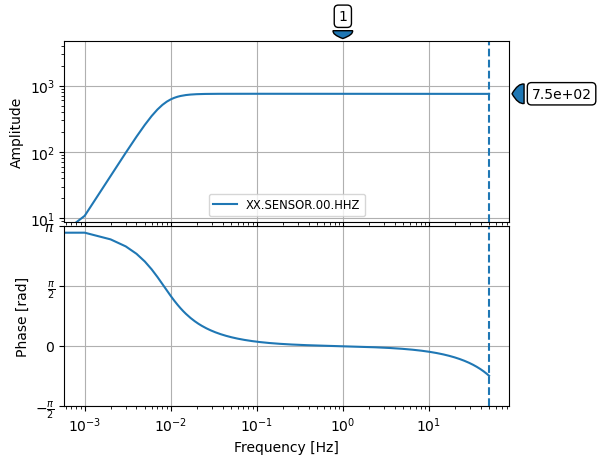

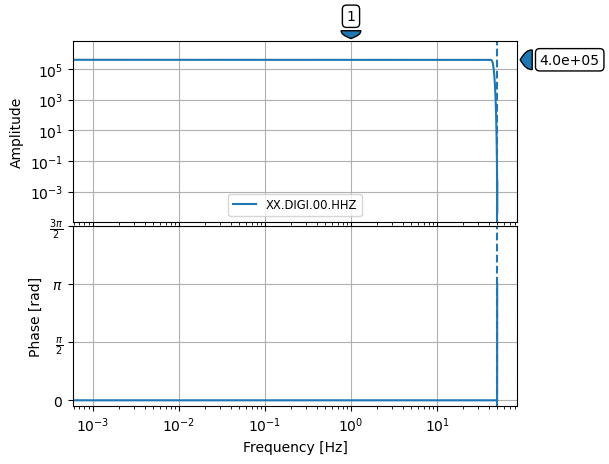

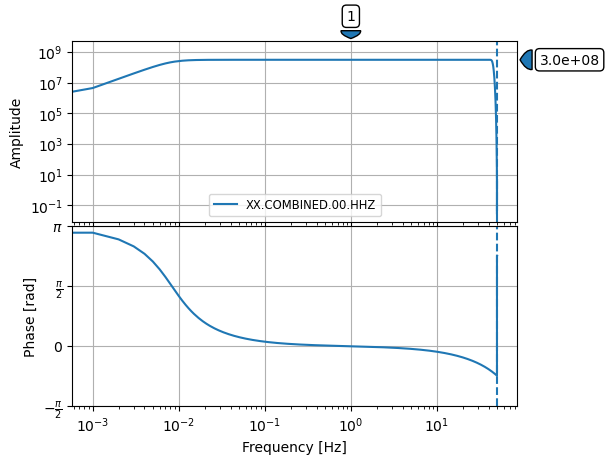

In [3]:
inv_sensor.plot_response(min_freq=0.001, output="VEL");
inv_digitizer.plot_response(min_freq=0.001, output="VEL");
inv_combined.plot_response(min_freq=0.001, output="VEL");

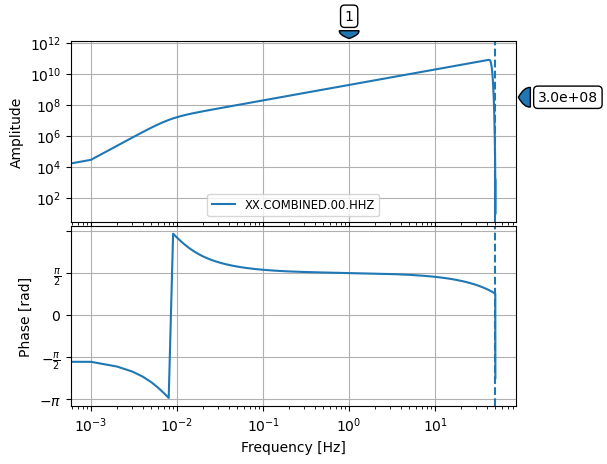

In [4]:
inv_combined.plot_response(min_freq=0.001, output="DISP");

## Choose a Raspberry Shake, and download & plot the response

RCD29 is one of my Raspberry Shake & Boom instruments.
* Shake: a geophone (high-frequency short-period seismometer, peaks at 4.5 Hz)
* Boom: an infrasound sensor

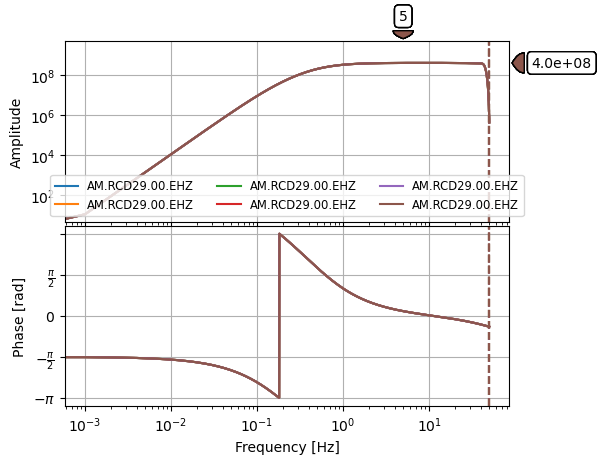

Stage 1: PolesZerosResponseStage, gain=399650000.0
Stage 2: CoefficientsTypeResponseStage, gain=1.0
Stage 3: FIRResponseStage, gain=1.0


In [5]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

rs = Client("RASPISHAKE")  # or Client("https://data.raspberryshake.org")
inv = rs.get_stations(network="AM", station="RCD29", channel='EHZ', level="response")
inv.plot_response(min_freq=0.001, output="VEL");

net = inv.select(network="AM", station="RCD29", channel="EHZ")[0]
sta = net.stations[0]
cha = sta.channels[0]
resp = cha.response
for i, stage in enumerate(resp.response_stages, start=1):
    print(f"Stage {i}: {type(stage).__name__}, gain={getattr(stage, 'stage_gain', None)}")



## Synthetic demo: deconvolution as *division* in the frequency domain

Below we simulate a near-delta pulse (a **Ricker wavelet**) as the "true" ground motion, apply an **instrument response** in the frequency domain,
and then "reconstitute" the signal by dividing by the frequency response (with a waterlevel to avoid blowing up noise where the response is tiny).

**Key identity** (frequency domain):

\[ X_{\text{obs}}(f) = H(f)\,X_{\text{true}}(f) \qquad\Rightarrow\qquad X_{\text{true}}(f) = \frac{X_{\text{obs}}(f)}{H(f)} \]

If you ran earlier cells that computed `resp_combined` (ObsPy `Response`) and/or created `inv_combined`, this section will use them automatically.
Otherwise it falls back to a simple toy bandpass response so the demo still runs.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import Trace, UTCDateTime

def ricker(t, f0):
    """Ricker wavelet centered at t=0 (a near-delta pulse), dominant frequency f0 (Hz)."""
    a = (np.pi * f0 * t)**2
    return (1.0 - 2.0*a) * np.exp(-a)

def amplitude_spectrum(x, dt):
    """One-sided amplitude spectrum."""
    n = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(n, d=dt)
    A = np.abs(X)
    return f, A, X

def _eval_H_from_response(resp, dt, nfft, output="VEL"):
    """Evaluate complex frequency response H(f) for an ObsPy Response via evalresp."""
    f = np.fft.rfftfreq(nfft, d=dt)
    try:
        freqs, H = resp.get_evalresp_response(t_samp=dt, nfft=nfft, output=output)
    except TypeError:
        freqs, H = resp.get_evalresp_response(t_samp=dt, nfft=nfft)
    H = np.asarray(H)
    if H.shape[0] == nfft:
        H = H[:len(f)]
    if freqs is not None:
        freqs = np.asarray(freqs)
        if freqs.shape[0] == nfft:
            freqs = freqs[:len(f)]
        if freqs.shape == f.shape:
            f = freqs
    return f, H

def toy_bandpass_H(f, f1=0.2, f2=30.0, order=4):
    """Simple smooth bandpass magnitude with zero phase (toy model)."""
    hp = 1.0 / np.sqrt(1.0 + (f1/np.maximum(f, 1e-12))**(2*order))
    lp = 1.0 / np.sqrt(1.0 + (np.maximum(f, 1e-12)/f2)**(2*order))
    return hp * lp + 0j


### 1) Simulate a "true" waveform: Ricker wavelet + a touch of noise

We build an ObsPy `Trace` so it feels like real workflow.


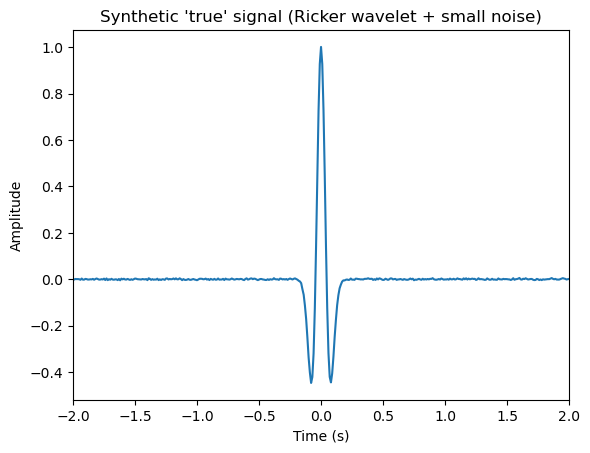

In [7]:
# Simulation parameters
sr = 100.0
dt = 1.0/sr
n = 4096
t = (np.arange(n) - n//2) * dt

# Near-delta pulse (Ricker)
f0 = 5.0  # dominant frequency (Hz)
x_true = ricker(t, f0)

# Add a little broadband noise (so you can *see* why waterlevel matters)
rng = np.random.default_rng(0)
x_true_noisy = x_true + 0.002 * rng.standard_normal(n)

tr_true = Trace(data=x_true_noisy.astype(np.float64))
tr_true.stats.starttime = UTCDateTime(2020, 1, 1)
tr_true.stats.sampling_rate = sr
tr_true.stats.channel = "HHZ"

plt.figure()
plt.plot(t, x_true_noisy)
plt.xlim(-2, 2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Synthetic 'true' signal (Ricker wavelet + small noise)")
plt.show()


### 2) Choose an instrument response H(f)

If `resp_combined` exists (from your NRL cells), we evaluate **its** complex response.
Otherwise we use a **toy** bandpass response (so the demo still works anywhere).


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


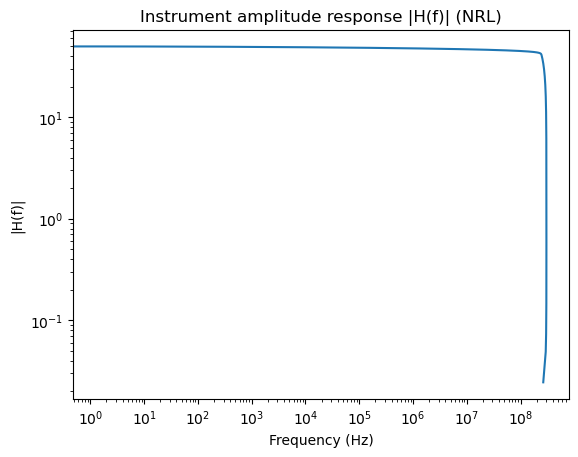

In [8]:
# Build frequency response H(f)
nfft = n
f = np.fft.rfftfreq(nfft, d=dt)

use_nrl = 'resp_combined' in globals()

if use_nrl:
    f_H, H = _eval_H_from_response(resp_combined, dt=dt, nfft=nfft, output="VEL")
    if f_H.shape == f.shape:
        f = f_H
else:
    H = toy_bandpass_H(f, f1=0.2, f2=30.0, order=4)

plt.figure()
plt.loglog(f[1:], np.abs(H)[1:])
plt.xlabel("Frequency (Hz)")
plt.ylabel("|H(f)|")
plt.title("Instrument amplitude response |H(f)|" + (" (NRL)" if use_nrl else " (toy bandpass)"))
plt.show()


### 3) "Record" the signal: apply the instrument in the frequency domain

We simulate what the digitizer would see:

\[ X_{\text{obs}}(f) = H(f)\,X_{\text{true}}(f) \]


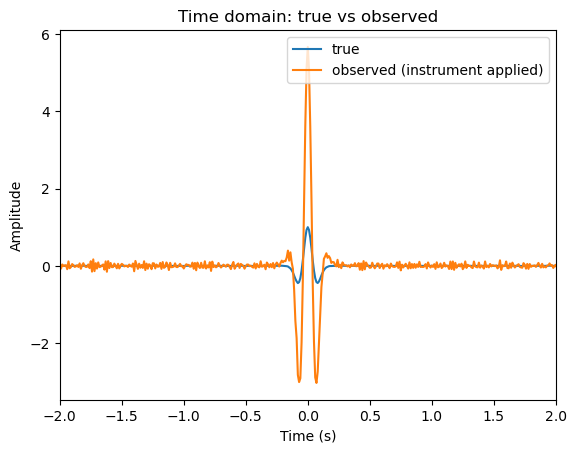

In [9]:
X_true = np.fft.rfft(x_true_noisy, n=nfft)
X_obs = H * X_true
x_obs = np.fft.irfft(X_obs, n=nfft)

plt.figure()
plt.plot(t, x_true_noisy, label="true")
plt.plot(t, x_obs, label="observed (instrument applied)")
plt.xlim(-2, 2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time domain: true vs observed")
plt.legend()
plt.show()


### 4) Reconstitute: divide by H(f) (with waterlevel)

Naively:

\[ X_{\text{rec}}(f) = X_{\text{obs}}(f) / H(f) \]

But where \(|H(f)|\) is tiny, this explodes noise. So we use a **waterlevel**.


/var/folders/yj/6sjdgxm52t5d_p4w0lcrsrzr0000gp/T/ipykernel_45381/2416667651.py:13: RuntimeWarning: invalid value encountered in divide
  X_rec = X_obs / H


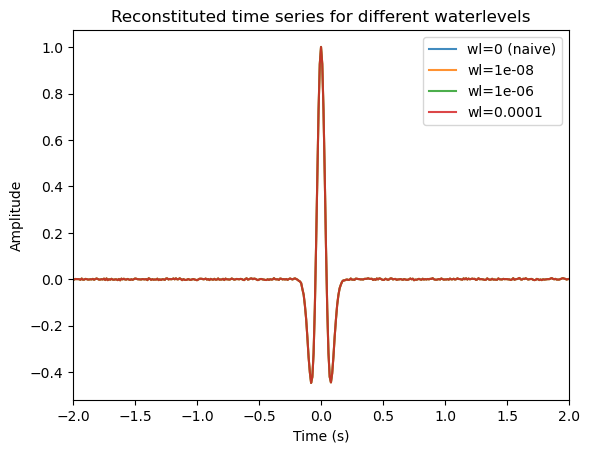

In [10]:
def deconvolve_divide(X_obs, H, waterlevel=1e-6):
    mag = np.abs(H)
    phase = np.exp(1j * np.angle(H))
    mag_safe = np.maximum(mag, waterlevel)
    H_safe = mag_safe * phase
    return X_obs / H_safe

waterlevels = [0.0, 1e-8, 1e-6, 1e-4]

plt.figure()
for wl in waterlevels:
    if wl == 0.0:
        X_rec = X_obs / H
        label = "wl=0 (naive)"
    else:
        X_rec = deconvolve_divide(X_obs, H, waterlevel=wl)
        label = f"wl={wl:g}"
    x_rec = np.fft.irfft(X_rec, n=nfft)
    plt.plot(t, x_rec, label=label, alpha=0.85)

plt.xlim(-2, 2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Reconstituted time series for different waterlevels")
plt.legend()
plt.show()


### 5) The money plot: spectra showing multiplication and division

We plot amplitude spectra for:

- \(|X_{\text{true}}(f)|\)
- \(|H(f)|\) (scaled just for visibility)
- \(|X_{\text{obs}}(f)| = |H(f)X_{\text{true}}(f)|\)
- \(|X_{\text{rec}}(f)| = |X_{\text{obs}}(f)/H(f)|\) (with waterlevel)

This makes “divide by the response” visually explicit.


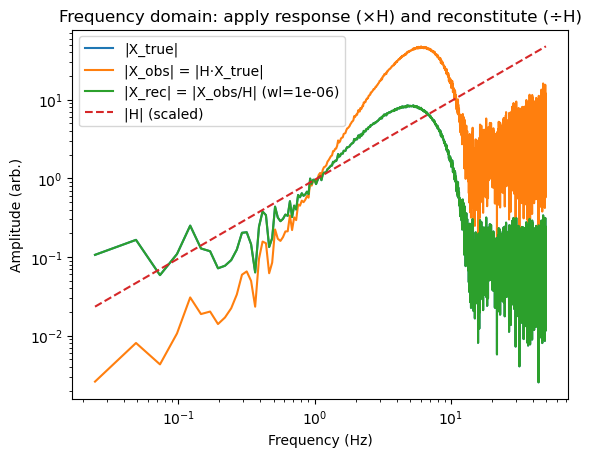

In [11]:
wl = 1e-6
X_rec = deconvolve_divide(X_obs, H, waterlevel=wl)

f_s, A_true, _ = amplitude_spectrum(x_true_noisy, dt)
_,   A_obs, _  = amplitude_spectrum(x_obs, dt)
_,   A_rec, _  = amplitude_spectrum(np.fft.irfft(X_rec, n=nfft), dt)

Hmag = np.abs(H)
Hmag_scaled = Hmag / (Hmag.max() if Hmag.max() > 0 else 1.0) * A_obs.max()

plt.figure()
plt.loglog(f_s[1:], A_true[1:], label="|X_true|")
plt.loglog(f_s[1:], A_obs[1:],  label="|X_obs| = |H·X_true|")
plt.loglog(f_s[1:], A_rec[1:],  label=f"|X_rec| = |X_obs/H| (wl={wl:g})")
plt.loglog(f_s[1:], Hmag_scaled[1:], label="|H| (scaled)", linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (arb.)")
plt.title("Frequency domain: apply response (×H) and reconstitute (÷H)")
plt.legend()
plt.show()
